<a href="https://colab.research.google.com/github/Lalith-Lavu/ATS-Lab-4/blob/main/ATS_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

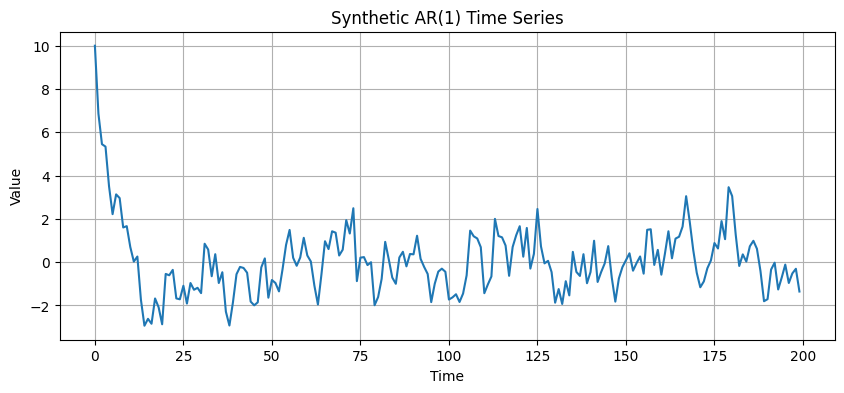

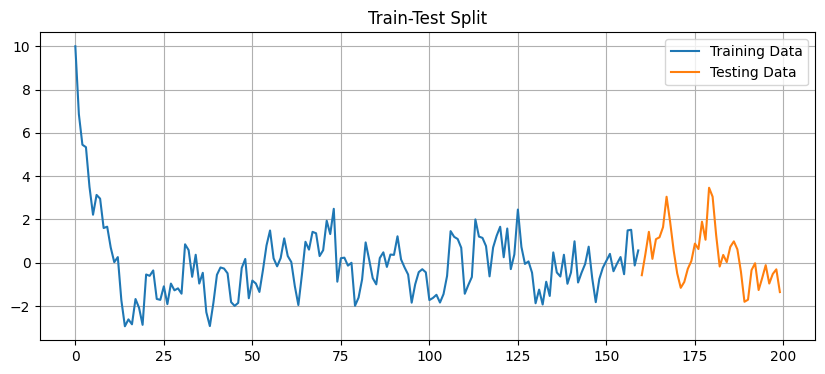

                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                  160
Model:                     AutoReg(1)   Log Likelihood                -214.977
Method:               Conditional MLE   S.D. of innovations              0.935
Date:                Mon, 05 Jan 2026   AIC                            435.954
Time:                        08:54:33   BIC                            445.161
Sample:                             1   HQIC                           439.693
                                  160                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0715      0.074     -0.964      0.335      -0.217       0.074
y.L1           0.6910      0.044     15.838      0.000       0.606       0.777
                                    Roots           

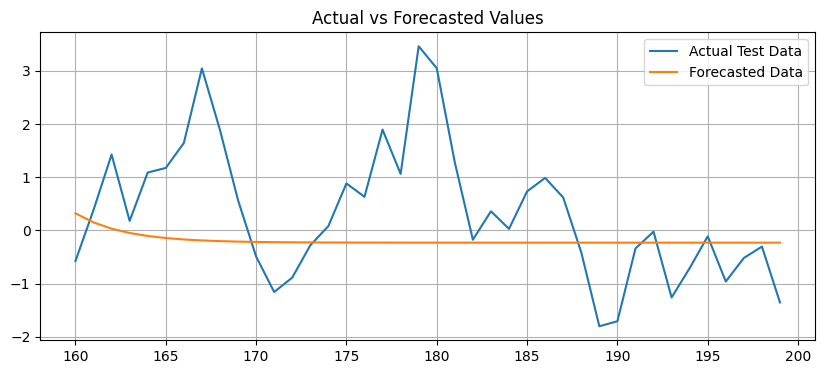

(1.8159037537886227, np.float64(1.3475547312775917))

In [ ]:
# LAB 4 — Autoregressive (AR) Modeling + Train–Test Split

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error


np.random.seed(42)
n = 200
phi = 0.7
noise = np.random.normal(0, 1, n)

x = [10]  # initial value
for t in range(1, n):
    x.append(phi * x[t-1] + noise[t])

data = pd.Series(x)

plt.figure(figsize=(10,4))
plt.plot(data)
plt.title("Synthetic AR(1) Time Series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True)
plt.show()


train_size = int(0.8 * n)
train = data[:train_size]
test = data[train_size:]

plt.figure(figsize=(10,4))
plt.plot(train, label="Training Data")
plt.plot(test, label="Testing Data")
plt.title("Train-Test Split")
plt.legend()
plt.grid(True)
plt.show()

model = AutoReg(train, lags=1).fit()
print(model.summary())

predictions = model.predict(start=train_size, end=n-1)

plt.figure(figsize=(10,4))
plt.plot(test.index, test, label="Actual Test Data")
plt.plot(test.index, predictions, label="Forecasted Data")
plt.title("Actual vs Forecasted Values")
plt.legend()
plt.grid(True)
plt.show()

mse = mean_squared_error(test, predictions)
rmse = np.sqrt(mse)

mse, rmse
